# Shanghai T1D/T2D — Temporal Fusion Transformer (TFT)

**Corrected Google Colab pipeline**

This notebook uses the longitudinal patient/session files from the Shanghai T1DM and Shanghai T2DM folders, **not** the `*_Summary.xlsx` files.

**Baseline setup**
- Input history: **120 minutes**
- Forecast horizons: **30 and 60 minutes**
- Sampling: **15 minutes**
- Encoder length: **8 time steps**
- Decoder length: **4 time steps** (60-minute maximum horizon)
- Target: **CGM (mg/dL)**
- Separate T1D and T2D evaluation
- Patient/session-level chronological splitting to reduce leakage
- PyTorch Forecasting TFT + QuantileLoss


In [2]:
# 1. Install dependencies
!pip install -q "pytorch-forecasting>=1.4" "lightning>=2.0" xlrd openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 35.2 MB/s eta 0:00:00


In [3]:
# 2. Imports
import os
import re
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl

from sklearn.metrics import mean_absolute_error, mean_squared_error

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# 3. Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [5]:
# 4. Dataset location

# Change this only if your extracted dataset is stored somewhere else.
DATA_DIR = Path("/content/drive/MyDrive/shangai")

print("DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

if DATA_DIR.exists():
    for p in DATA_DIR.iterdir():
        print(p)


DATA_DIR: /content/drive/MyDrive/shangai
Exists: True
/content/drive/MyDrive/shangai/data_analysis.ipynb
/content/drive/MyDrive/shangai/note.txt
/content/drive/MyDrive/shangai/Shanghai_T1DM_Summary.xlsx
/content/drive/MyDrive/shangai/Shanghai_T2DM_Summary.xlsx
/content/drive/MyDrive/shangai/Shanghai_T1DM
/content/drive/MyDrive/shangai/__MACOSX
/content/drive/MyDrive/shangai/Shanghai_T2DM


In [6]:
# 5. Locate the actual longitudinal Shanghai files

# We intentionally exclude:
#   Shanghai_T1DM_Summary.xlsx
#   Shanghai_T2DM_Summary.xlsx
#   __MACOSX metadata
#
# The files we want are the individual patient/session files.

T1_DIR = DATA_DIR / "Shanghai_T1DM"
T2_DIR = DATA_DIR / "Shanghai_T2DM"

def valid_data_file(p):
    return (
        p.is_file()
        and p.suffix.lower() in {".xlsx", ".xls"}
        and "__MACOSX" not in str(p)
        and not p.name.startswith("._")
    )

T1_FILES = sorted([p for p in T1_DIR.rglob("*") if valid_data_file(p)])
T2_FILES = sorted([p for p in T2_DIR.rglob("*") if valid_data_file(p)])

print("T1D files:", len(T1_FILES))
print("T2D files:", len(T2_FILES))

print("\nFirst T1D files:")
for p in T1_FILES[:10]:
    print(" ", p.name)

print("\nFirst T2D files:")
for p in T2_FILES[:10]:
    print(" ", p.name)

if not T1_FILES:
    raise FileNotFoundError(f"No T1D Excel files found in {T1_DIR}")

if not T2_FILES:
    raise FileNotFoundError(f"No T2D Excel files found in {T2_DIR}")


T1D files: 16
T2D files: 109

First T1D files:
  1001_0_20210730.xlsx
  1002_0_20210504.xls
  1002_1_20210521.xls
  1002_2_20210909.xls
  1003_0_20210831.xls
  1004_0_20210425.xls
  1005_0_20210522.xls
  1006_0_20210114.xlsx
  1006_1_20210209.xlsx
  1006_2_20210303.xlsx

First T2D files:
  2000_0_20201230.xlsx
  2001_0_20201102.xlsx
  2001_1_20201117.xlsx
  2002_0_20210513.xlsx
  2003_0_20210615.xlsx
  2004_0_20211028.xlsx
  2005_0_20211201.xlsx
  2006_0_20211112.xlsx
  2007_0_20220108.xlsx
  2008_0_20220118.xlsx


In [7]:
# 6. Read one file and inspect its structure

def read_excel_file(path):
    path = Path(path)
    if path.suffix.lower() == ".xls":
        return pd.read_excel(path, engine="xlrd")
    return pd.read_excel(path, engine="openpyxl")

sample_t1 = read_excel_file(T1_FILES[0])
sample_t2 = read_excel_file(T2_FILES[0])

print("T1D sample:", T1_FILES[0].name)
print("Shape:", sample_t1.shape)
print(sample_t1.columns.tolist())
display(sample_t1.head())

print("\nT2D sample:", T2_FILES[0].name)
print("Shape:", sample_t2.shape)
print(sample_t2.columns.tolist())
display(sample_t2.head())


T1D sample: 1001_0_20210730.xlsx
Shape: (658, 11)
['Date', 'CGM (mg / dl)', 'CBG (mg / dl)', 'Blood Ketone (mmol / L)', 'Dietary intake', '饮食', 'Insulin dose - s.c.', 'Non-insulin hypoglycemic agents', 'CSII - bolus insulin (Novolin R, IU)', 'CSII - basal insulin (Novolin R, IU / H)', 'Insulin dose - i.v.']


,Date,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Dietary intake,饮食,Insulin dose - s.c.,Non-insulin hypoglycemic agents,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.
0,2021-07-30 16:43:00,113.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN
1,2021-07-30 16:58:00,124.2,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
2,2021-07-30 17:13:00,129.6,NaN,NaN,data not available,未记录,NaN,NaN,NaN,NaN,NaN
3,2021-07-30 17:28:00,142.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-07-30 17:43:00,156.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



T2D sample: 2000_0_20201230.xlsx
Shape: (1339, 11)
['Date', 'CGM (mg / dl)', 'CBG (mg / dl)', 'Blood Ketone (mmol / L)', 'Dietary intake', '饮食', 'Insulin dose - s.c.', 'Non-insulin hypoglycemic agents', 'CSII - bolus insulin (Novolin R, IU)', 'CSII - basal insulin (Novolin R, IU / H)', 'Insulin dose - i.v.']


,Date,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Dietary intake,饮食,Insulin dose - s.c.,Non-insulin hypoglycemic agents,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.
0,2020-12-30 13:54:00,138.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-12-30 14:09:00,120.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-12-30 14:24:00,106.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-30 14:39:00,97.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-12-30 14:54:00,88.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# 7. Parse patient/session identity from filenames

# Examples:
#   1006_1_20210209.xlsx
#   2020_0_20210615.xls
#
# We keep the complete filename stem as the session identifier.
# Patient ID is the first numeric component.

def parse_ids(path, diabetes_type):
    stem = Path(path).stem
    parts = stem.split("_")

    patient_id = parts[0] if parts else stem
    session_id = stem

    return str(patient_id), str(session_id)

print(parse_ids(T1_FILES[0], "T1D"))


('1001', '1001_0_20210730')


In [9]:
# 8. Standardize one longitudinal file

DATE_COL = "Date"
GLUCOSE_COL = "CGM (mg / dl)"

def standardize_file(path, diabetes_type):
    df = read_excel_file(path).copy()

    missing = [c for c in [DATE_COL, GLUCOSE_COL] if c not in df.columns]
    if missing:
        raise ValueError(
            f"{path.name}: missing {missing}. "
            f"Available columns: {df.columns.tolist()}"
        )

    patient_id, session_id = parse_ids(path, diabetes_type)

    out = pd.DataFrame({
        "diabetes_type": diabetes_type,
        "patient_id": patient_id,
        "session_id": session_id,
        "timestamp": pd.to_datetime(df[DATE_COL], errors="coerce"),
        "glucose": pd.to_numeric(df[GLUCOSE_COL], errors="coerce"),
    })

    # Keep optional variables when available.
    optional_map = {
        "cbg": "CBG (mg / dl)",
        "blood_ketone": "Blood Ketone (mmol / L)",
        "dietary_intake": "Dietary intake",
        "insulin_sc": "Insulin dose - s.c.",
        "non_insulin_agents": "Non-insulin hypoglycemic agents",
        "csii_bolus": "CSII - bolus insulin",
        "csii_basal": "CSII - basal insulin",
        "insulin_iv": "Insulin dose - i.v.",
    }

    for new_col, old_col in optional_map.items():
        if old_col in df.columns:
            out[new_col] = df[old_col]

    # Remove invalid timestamp / glucose rows.
    out = out.dropna(subset=["timestamp", "glucose"])

    # Keep physiologically plausible values for this baseline.
    # This does NOT invent missing glucose values.
    out = out[(out["glucose"] >= 20) & (out["glucose"] <= 600)]

    out = out.sort_values("timestamp").drop_duplicates(
        subset=["timestamp"], keep="first"
    )

    return out.reset_index(drop=True)

test = standardize_file(T1_FILES[0], "T1D")
print(test.shape)
display(test.head())


(658, 11)


,diabetes_type,patient_id,session_id,timestamp,glucose,cbg,blood_ketone,dietary_intake,insulin_sc,non_insulin_agents,insulin_iv
0,T1D,1001,1001_0_20210730,2021-07-30 16:43:00,113.4,NaN,NaN,NaN,NaN,NaN,NaN
1,T1D,1001,1001_0_20210730,2021-07-30 16:58:00,124.2,NaN,NaN,NaN,NaN,NaN,NaN
2,T1D,1001,1001_0_20210730,2021-07-30 17:13:00,129.6,NaN,NaN,data not available,NaN,NaN,NaN
3,T1D,1001,1001_0_20210730,2021-07-30 17:28:00,142.2,NaN,NaN,NaN,NaN,NaN,NaN
4,T1D,1001,1001_0_20210730,2021-07-30 17:43:00,156.6,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# 9. Load all T1D and T2D longitudinal files

def load_dataset(file_list, diabetes_type):
    frames = []
    errors = []

    for i, path in enumerate(file_list, start=1):
        try:
            x = standardize_file(path, diabetes_type)

            if len(x) > 0:
                frames.append(x)

            if i % 20 == 0 or i == len(file_list):
                print(f"{diabetes_type}: processed {i}/{len(file_list)}")

        except Exception as e:
            errors.append((str(path), str(e)))

    data = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    return data, errors

t1d, t1_errors = load_dataset(T1_FILES, "T1D")
t2d, t2_errors = load_dataset(T2_FILES, "T2D")

print("\nT1D:", t1d.shape)
print("T2D:", t2d.shape)

print("\nT1D errors:", len(t1_errors))
print("T2D errors:", len(t2_errors))

if t1_errors:
    print("\nFirst T1D error:", t1_errors[0])

if t2_errors:
    print("\nFirst T2D error:", t2_errors[0])


T1D: processed 16/16
T2D: processed 20/109
T2D: processed 40/109
T2D: processed 60/109
T2D: processed 80/109
T2D: processed 100/109
T2D: processed 109/109

T1D: (15695, 11)
T2D: (109794, 11)

T1D errors: 0
T2D errors: 2

First T2D error: ('/content/drive/MyDrive/shangai/Shanghai_T2DM/2045_0_20201216.xls', "2045_0_20201216.xls: missing ['CGM (mg / dl)']. Available columns: ['Date', 'CGM ', 'CBG ', 'Blood Ketone ', 'Dietary intake', '饮食', 'Insulin dose - s.c.', 'Non-insulin hypoglycemic agents', 'CSII - bolus insulin ', 'CSII - basal insulin ', 'Insulin dose - i.v.']")


In [11]:
# 10. Combine and inspect

data = pd.concat([t1d, t2d], ignore_index=True)

print("Combined shape:", data.shape)
print("\nDiabetes type:")
print(data["diabetes_type"].value_counts())

print("\nUnique patients:")
print(data.groupby("diabetes_type")["patient_id"].nunique())

print("\nUnique sessions:")
print(data.groupby("diabetes_type")["session_id"].nunique())

display(data.head())


Combined shape: (125489, 11)

Diabetes type:
diabetes_type
T2D    109794
T1D     15695
Name: count, dtype: int64

Unique patients:
diabetes_type
T1D    12
T2D    98
Name: patient_id, dtype: int64

Unique sessions:
diabetes_type
T1D     16
T2D    107
Name: session_id, dtype: int64


,diabetes_type,patient_id,session_id,timestamp,glucose,cbg,blood_ketone,dietary_intake,insulin_sc,non_insulin_agents,insulin_iv
0,T1D,1001,1001_0_20210730,2021-07-30 16:43:00,113.4,NaN,NaN,NaN,NaN,NaN,NaN
1,T1D,1001,1001_0_20210730,2021-07-30 16:58:00,124.2,NaN,NaN,NaN,NaN,NaN,NaN
2,T1D,1001,1001_0_20210730,2021-07-30 17:13:00,129.6,NaN,NaN,data not available,NaN,NaN,NaN
3,T1D,1001,1001_0_20210730,2021-07-30 17:28:00,142.2,NaN,NaN,NaN,NaN,NaN,NaN
4,T1D,1001,1001_0_20210730,2021-07-30 17:43:00,156.6,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# 11. Check sampling intervals

def interval_summary(df):
    x = df.sort_values(["session_id", "timestamp"]).copy()
    x["delta_min"] = (
        x.groupby("session_id")["timestamp"]
         .diff()
         .dt.total_seconds()
         .div(60)
    )
    return x["delta_min"].describe()

print("T1D interval summary:")
print(interval_summary(t1d))

print("\nT2D interval summary:")
print(interval_summary(t2d))


T1D interval summary:
count    15679.000000
mean        15.000957
std          0.119793
min         15.000000
25%         15.000000
50%         15.000000
75%         15.000000
max         30.000000
Name: delta_min, dtype: float64

T2D interval summary:
count    109687.000000
mean         15.003027
std           0.626725
min          15.000000
25%          15.000000
50%          15.000000
75%          15.000000
max         212.000000
Name: delta_min, dtype: float64


In [13]:
# 12. Resample each session to 15-minute intervals

# We resample glucose independently within each session.
# Only short gaps are interpolated. Long gaps remain missing.

RESAMPLE_FREQ = "15min"
MAX_INTERPOLATION_STEPS = 2  # at most 30 minutes of interpolation

def resample_session(group):
    group = group.sort_values("timestamp").copy()
    session_id = group["session_id"].iloc[0]
    patient_id = group["patient_id"].iloc[0]
    diabetes_type = group["diabetes_type"].iloc[0]

    x = group.set_index("timestamp")

    # Preserve glucose and optional numeric features when possible.
    numeric_cols = ["glucose"]
    for c in [
        "cbg", "blood_ketone", "insulin_sc",
        "csii_bolus", "csii_basal", "insulin_iv"
    ]:
        if c in x.columns:
            x[c] = pd.to_numeric(x[c], errors="coerce")
            numeric_cols.append(c)

    x = x[numeric_cols].resample(RESAMPLE_FREQ).mean()

    # Interpolate ONLY short missing runs.
    for c in numeric_cols:
        x[c] = x[c].interpolate(
            method="time",
            limit=MAX_INTERPOLATION_STEPS,
            limit_direction="both"
        )

    x["session_id"] = session_id
    x["patient_id"] = patient_id
    x["diabetes_type"] = diabetes_type

    return x.reset_index()

resampled_parts = []

for session_id, g in data.groupby("session_id", sort=False):
    r = resample_session(g)
    if len(r) > 0:
        resampled_parts.append(r)

data_15 = pd.concat(resampled_parts, ignore_index=True)

data_15 = data_15.dropna(subset=["glucose"])
data_15 = data_15.sort_values(["session_id", "timestamp"]).reset_index(drop=True)

print("After 15-minute resampling:", data_15.shape)
display(data_15.head())


After 15-minute resampling: (125503, 9)


,timestamp,glucose,cbg,blood_ketone,insulin_sc,insulin_iv,session_id,patient_id,diabetes_type
0,2021-07-30 16:30:00,113.4,NaN,NaN,NaN,NaN,1001_0_20210730,1001,T1D
1,2021-07-30 16:45:00,124.2,NaN,NaN,NaN,NaN,1001_0_20210730,1001,T1D
2,2021-07-30 17:00:00,129.6,NaN,NaN,NaN,NaN,1001_0_20210730,1001,T1D
3,2021-07-30 17:15:00,142.2,NaN,NaN,NaN,NaN,1001_0_20210730,1001,T1D
4,2021-07-30 17:30:00,156.6,NaN,NaN,NaN,NaN,1001_0_20210730,1001,T1D


In [14]:
# 13. Basic data quality summary

print("Rows:", len(data_15))
print("Sessions:", data_15["session_id"].nunique())
print("Patients:", data_15["patient_id"].nunique())

print("\nRows by diabetes type:")
print(data_15.groupby("diabetes_type").size())

print("\nGlucose summary:")
display(data_15.groupby("diabetes_type")["glucose"].describe())


Rows: 125503
Sessions: 123
Patients: 110

Rows by diabetes type:
diabetes_type
T1D     15696
T2D    109807
dtype: int64

Glucose summary:


,count,mean,std,min,25%,50%,75%,max
diabetes_type,,,,,,,,
T1D,15696.0,164.745872,72.314519,39.6,108.0,156.6,214.2,475.2
T2D,109807.0,138.804372,49.585796,39.6,102.6,129.6,165.6,468.0


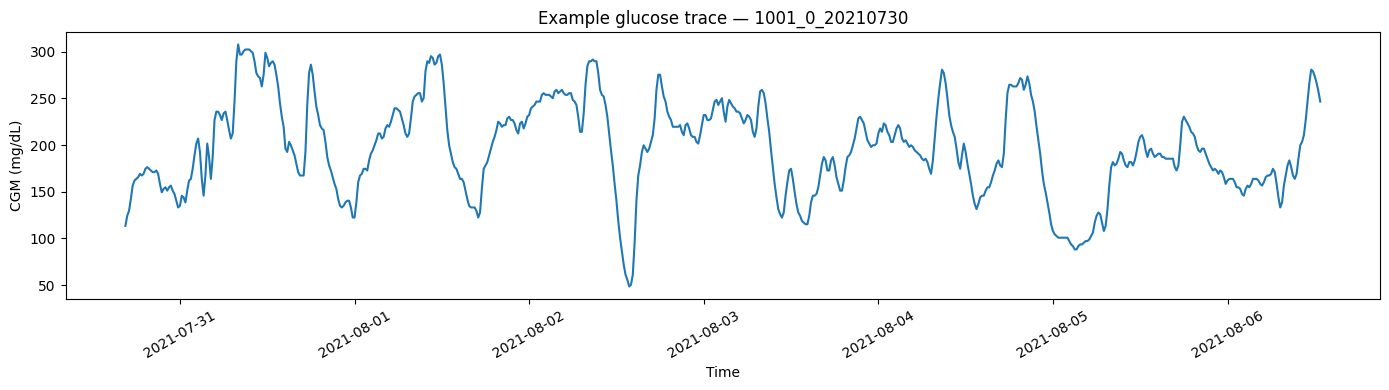

In [15]:
# 14. Plot an example glucose trace

example_session = data_15["session_id"].iloc[0]
plot_df = data_15[data_15["session_id"] == example_session].copy()

plt.figure(figsize=(14, 4))
plt.plot(plot_df["timestamp"], plot_df["glucose"])
plt.xlabel("Time")
plt.ylabel("CGM (mg/dL)")
plt.title(f"Example glucose trace — {example_session}")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [16]:
# 15. Create a regular time index for TFT

# TFT requires an integer time index.
# Since the data is already resampled to 15 minutes,
# each 15-minute step advances time_idx by 1.

data_15["time_idx"] = (
    data_15.groupby("session_id").cumcount().astype(int)
)

# A session must contain enough observations for:
# 8 encoder steps + 4 decoder steps = 12 total steps.
session_lengths = data_15.groupby("session_id").size()

valid_sessions = session_lengths[session_lengths >= 12].index

data_15 = data_15[data_15["session_id"].isin(valid_sessions)].copy()

print("Valid sessions:", data_15["session_id"].nunique())
print("Rows:", len(data_15))


Valid sessions: 123
Rows: 125503


In [17]:
# 16. Leakage-safe chronological split by SESSION

# We split each session chronologically:
#   70% train
#   15% validation
#   15% test
#
# This means future observations are never used to train the model.

def assign_split(group):
    group = group.sort_values("timestamp").copy()
    n = len(group)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    group["split"] = "test"
    group.iloc[:train_end, group.columns.get_loc("split")] = "train"
    group.iloc[train_end:val_end, group.columns.get_loc("split")] = "val"

    return group

split_parts = [
    assign_split(g)
    for _, g in data_15.groupby("session_id", sort=False)
]

model_df = pd.concat(split_parts, ignore_index=True)

print(model_df["split"].value_counts())
print("\nBy diabetes type:")
display(pd.crosstab(model_df["diabetes_type"], model_df["split"]))


split
train    87793
test     18875
val      18835
Name: count, dtype: int64

By diabetes type:


split,test,train,val
diabetes_type,,,
T1D,2362,10979,2355
T2D,16513,76814,16480


In [18]:
# 17. IMPORTANT: make separate T1D and T2D datasets

# We train/evaluate T1D and T2D separately so that
# performance can be reported independently.

T1D_MODEL = model_df[model_df["diabetes_type"] == "T1D"].copy()
T2D_MODEL = model_df[model_df["diabetes_type"] == "T2D"].copy()

print("T1D:", T1D_MODEL.shape)
print("T2D:", T2D_MODEL.shape)


T1D: (15696, 11)
T2D: (109807, 11)


In [19]:
# 18. TFT settings

ENCODER_LENGTH = 8       # 8 x 15 min = 120 minutes
PREDICTION_LENGTH = 4    # 4 x 15 min = 60 minutes

BATCH_SIZE = 64
MAX_EPOCHS = 30

SEED = 42
pl.seed_everything(SEED, workers=True)

print("Encoder:", ENCODER_LENGTH, "steps =", ENCODER_LENGTH * 15, "minutes")
print("Decoder:", PREDICTION_LENGTH, "steps =", PREDICTION_LENGTH * 15, "minutes")


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Encoder: 8 steps = 120 minutes
Decoder: 4 steps = 60 minutes


In [20]:
# 19. Build TimeSeriesDataSet objects

# We use only historical glucose as the baseline predictor.
# Grouping by session prevents information from one patient/session
# being mixed with another.

def build_datasets(df):
    train_df = df[df["split"] == "train"].copy()
    val_df = df[df["split"] == "val"].copy()
    test_df = df[df["split"] == "test"].copy()

    # Make time_idx start consistently within each session.
    train_df["time_idx"] = train_df.groupby("session_id").cumcount()

    # Validation/test need the same relative time indexing.
    full_order = df.sort_values(["session_id", "timestamp"]).copy()
    full_order["time_idx"] = full_order.groupby("session_id").cumcount()

    train_df = full_order[full_order["split"] == "train"].copy()
    val_df = full_order[full_order["split"] == "val"].copy()
    test_df = full_order[full_order["split"] == "test"].copy()

    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target="glucose",
        group_ids=["session_id"],

        min_encoder_length=ENCODER_LENGTH,
        max_encoder_length=ENCODER_LENGTH,
        min_prediction_length=PREDICTION_LENGTH,
        max_prediction_length=PREDICTION_LENGTH,

        static_categoricals=["diabetes_type"],

        time_varying_known_reals=["time_idx"],
        time_varying_unknown_reals=["glucose"],

        target_normalizer=GroupNormalizer(
            groups=["session_id"],
            transformation="softplus"
        ),

        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    # Validation/test datasets are constructed from the full ordered
    # dataframe using the training dataset's encoder/normalization setup.
    validation = TimeSeriesDataSet.from_dataset(
        training,
        val_df,
        predict=False,
        stop_randomization=True,
    )

    test = TimeSeriesDataSet.from_dataset(
        training,
        test_df,
        predict=False,
        stop_randomization=True,
    )

    return training, validation, test

# Build separately
t1_training, t1_validation, t1_test = build_datasets(T1D_MODEL)
t2_training, t2_validation, t2_test = build_datasets(T2D_MODEL)

print("T1D training samples:", len(t1_training))
print("T1D validation samples:", len(t1_validation))
print("T1D test samples:", len(t1_test))

print("\nT2D training samples:", len(t2_training))
print("T2D validation samples:", len(t2_validation))
print("T2D test samples:", len(t2_test))


T1D training samples: 10803
T1D validation samples: 2179
T1D test samples: 2186

T2D training samples: 75637
T2D validation samples: 15303
T2D test samples: 15336


In [21]:
# 20. DataLoaders

def make_loaders(training, validation, test):
    train_loader = training.to_dataloader(
        train=True,
        batch_size=BATCH_SIZE,
        num_workers=0
    )

    val_loader = validation.to_dataloader(
        train=False,
        batch_size=BATCH_SIZE,
        num_workers=0
    )

    test_loader = test.to_dataloader(
        train=False,
        batch_size=BATCH_SIZE,
        num_workers=0
    )

    return train_loader, val_loader, test_loader

t1_train_loader, t1_val_loader, t1_test_loader = make_loaders(
    t1_training, t1_validation, t1_test
)

t2_train_loader, t2_val_loader, t2_test_loader = make_loaders(
    t2_training, t2_validation, t2_test
)


In [22]:
# 21. Train one TFT model

def train_tft(training, train_loader, val_loader, name):
    checkpoint = ModelCheckpoint(
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        filename=f"{name}-{{epoch:02d}}-{{val_loss:.4f}}"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min"
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[checkpoint, early_stop],
        enable_model_summary=True,
        log_every_n_steps=20,
    )

    model = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=0.001,
        hidden_size=32,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=16,
        loss=QuantileLoss(),
        output_size=7,
        reduce_on_plateau_patience=3,
    )

    print(f"\nTraining {name}...")
    trainer.fit(
        model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader
    )

    print("Best checkpoint:", checkpoint.best_model_path)

    best_model = TemporalFusionTransformer.load_from_checkpoint(
        checkpoint.best_model_path
    )

    return best_model, trainer, checkpoint.best_model_path


In [23]:

# 22. Train T1D TFT

t1_model, t1_trainer, T1_CHECKPOINT = train_tft(
    t1_training,
    t1_train_loader,
    t1_val_loader,
    "T1D_TFT"
)

print("T1D checkpoint:", T1_CHECKPOINT)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training T1D_TFT...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    192 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 68.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 68.4 K                                                                                               
Total estimated model params size (MB): 0.274                                                                      
Modules in train mode: 284                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Best checkpoint: /content/lightning_logs/version_0/checkpoints/T1D_TFT-epoch=11-val_loss=7.5943.ckpt
T1D checkpoint: /content/lightning_logs/version_0/checkpoints/T1D_TFT-epoch=11-val_loss=7.5943.ckpt


In [24]:
# 23. Train T2D TFT

t2_model, t2_trainer, T2_CHECKPOINT = train_tft(
    t2_training,
    t2_train_loader,
    t2_val_loader,
    "T2D_TFT"
)

print("T2D checkpoint:", T2_CHECKPOINT)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Training T2D_TFT...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    192 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 68.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 68.4 K                                                                                               
Total estimated model params size (MB): 0.274                                                                      
Modules in train mode: 284                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Best checkpoint: /content/lightning_logs/version_1/checkpoints/T2D_TFT-epoch=19-val_loss=5.4695.ckpt
T2D checkpoint: /content/lightning_logs/version_1/checkpoints/T2D_TFT-epoch=19-val_loss=5.4695.ckpt


In [25]:
 # 24. Prediction helper

def get_predictions(model, loader):
    raw = model.predict(
        loader,
        mode="raw",
        return_x=True
    )

    # point prediction = median quantile (index 3 for 7 quantiles)
    prediction = raw.output.prediction.detach().cpu().numpy()
    x = raw.x

    return prediction, x

t1_pred, t1_x = get_predictions(t1_model, t1_test_loader)
t2_pred, t2_x = get_predictions(t2_model, t2_test_loader)

print("T1D prediction shape:", t1_pred.shape)
print("T2D prediction shape:", t2_pred.shape)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

T1D prediction shape: (2186, 4, 7)
T2D prediction shape: (15336, 4, 7)


In [26]:
# 25. Extract actual target values

def extract_actuals(x):
    # decoder_target contains the true future glucose values.
    y = x["decoder_target"].detach().cpu().numpy()
    return y

t1_actual = extract_actuals(t1_x)
t2_actual = extract_actuals(t2_x)

print("T1D actual:", t1_actual.shape)
print("T2D actual:", t2_actual.shape)


T1D actual: (2186, 4)
T2D actual: (15336, 4)


In [27]:
# 26. RMSE / MAE / MAPE for 30 and 60 minutes

def calculate_metrics(actual, prediction):
    # prediction shape: [samples, 4, quantiles]
    # Median is quantile index 3 for QuantileLoss quantiles.
    if prediction.ndim == 3:
        point = prediction[:, :, 3]
    else:
        point = prediction

    rows = []

    for step, minutes in [(1, 30), (2, 60)]:
        y_true = actual[:, step - 1]
        y_pred = point[:, step - 1]

        mask = np.isfinite(y_true) & np.isfinite(y_pred)

        yt = y_true[mask]
        yp = y_pred[mask]

        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae = mean_absolute_error(yt, yp)

        nonzero = np.abs(yt) > 1e-6
        mape = (
            np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100
            if nonzero.any() else np.nan
        )

        rows.append({
            "horizon": f"{minutes} min",
            "RMSE_mg_dL": rmse,
            "MAE_mg_dL": mae,
            "MAPE_percent": mape,
            "N": len(yt)
        })

    return pd.DataFrame(rows)

t1_metrics = calculate_metrics(t1_actual, t1_pred)
t2_metrics = calculate_metrics(t2_actual, t2_pred)

print("T1D metrics")
display(t1_metrics)

print("T2D metrics")
display(t2_metrics)


T1D metrics


,horizon,RMSE_mg_dL,MAE_mg_dL,MAPE_percent,N
0,30 min,8.322114,5.773434,4.895056,2186
1,60 min,15.082920,11.077816,9.002938,2186


T2D metrics


,horizon,RMSE_mg_dL,MAE_mg_dL,MAPE_percent,N
0,30 min,5.761351,4.008970,3.181888,15336
1,60 min,12.295700,8.527192,6.612083,15336


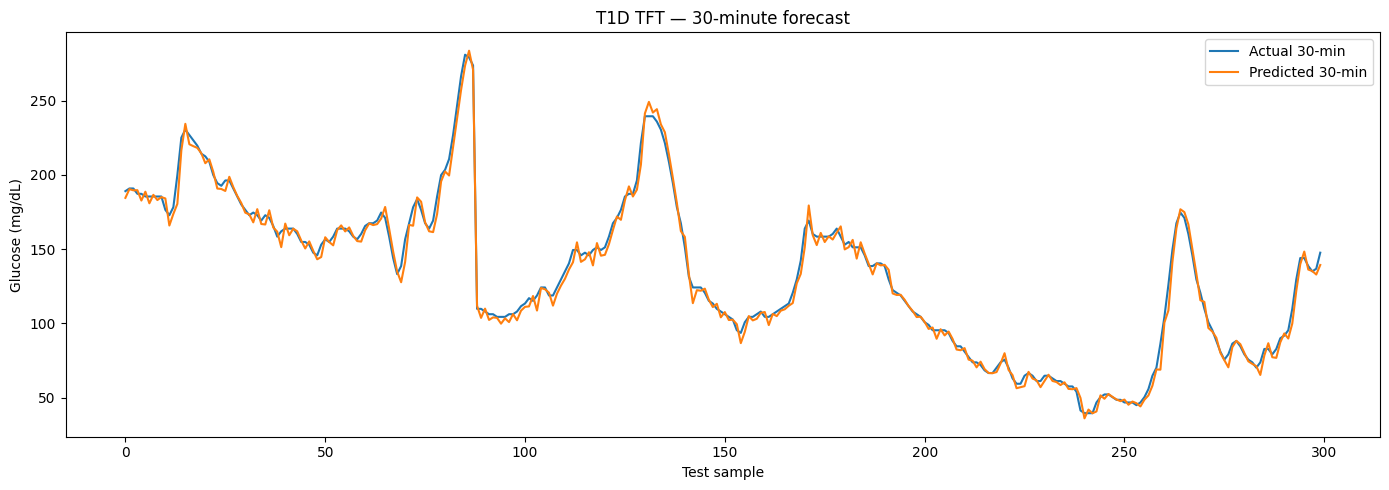

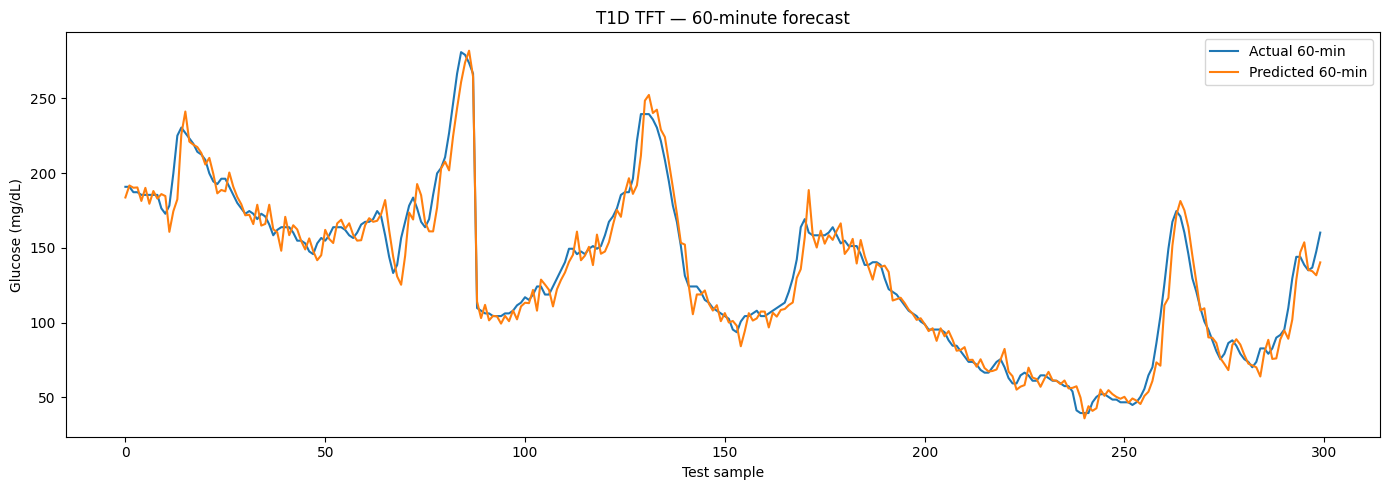

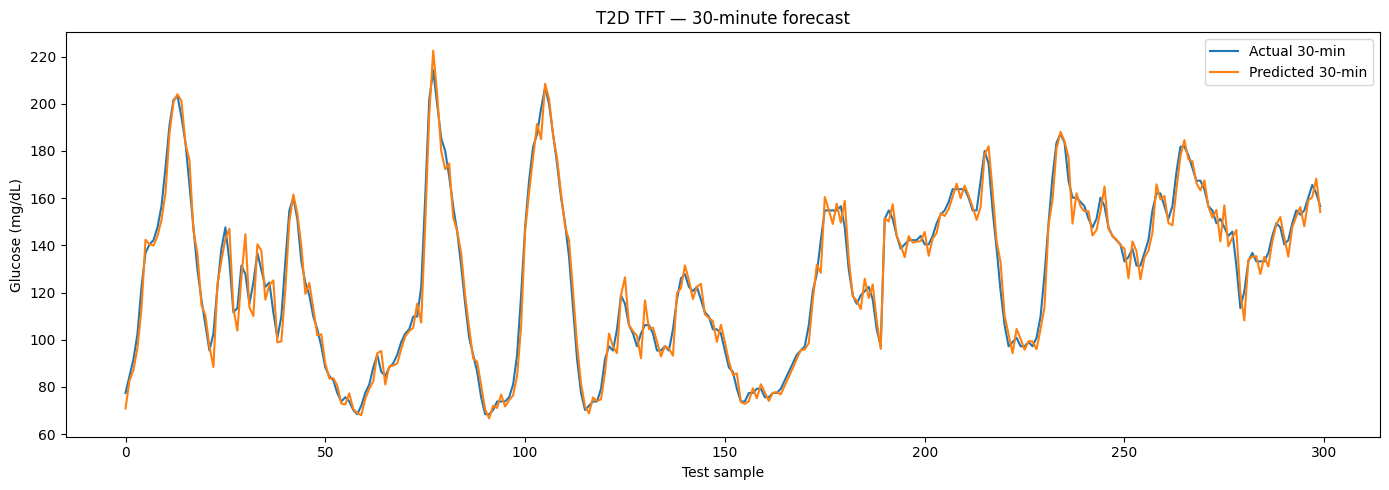

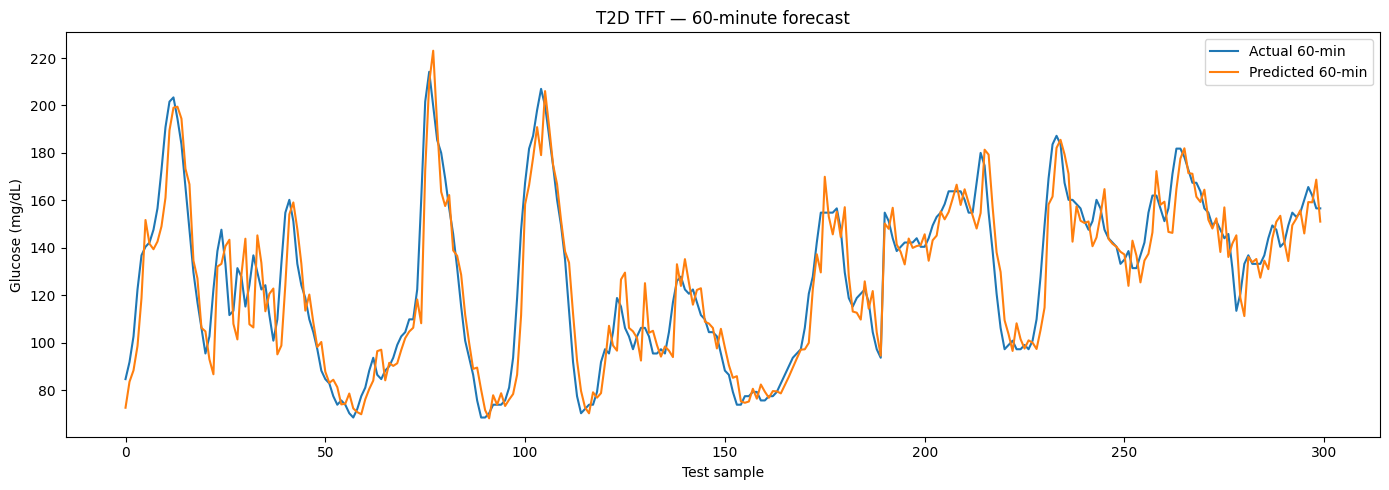

In [28]:
# 27. Plot actual vs predicted glucose

def plot_predictions(actual, prediction, title):
    point = prediction[:, :, 3]

    n = min(300, len(actual))

    plt.figure(figsize=(14, 5))
    plt.plot(actual[:n, 0], label="Actual 30-min")
    plt.plot(point[:n, 0], label="Predicted 30-min")
    plt.xlabel("Test sample")
    plt.ylabel("Glucose (mg/dL)")
    plt.title(title + " — 30-minute forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(actual[:n, 1], label="Actual 60-min")
    plt.plot(point[:n, 1], label="Predicted 60-min")
    plt.xlabel("Test sample")
    plt.ylabel("Glucose (mg/dL)")
    plt.title(title + " — 60-minute forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_predictions(t1_actual, t1_pred, "T1D TFT")
plot_predictions(t2_actual, t2_pred, "T2D TFT")


In [29]:
# 28. Save metrics and predictions

OUTPUT_DIR = DATA_DIR / "TFT_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

t1_metrics.to_csv(OUTPUT_DIR / "T1D_metrics.csv", index=False)
t2_metrics.to_csv(OUTPUT_DIR / "T2D_metrics.csv", index=False)

np.save(OUTPUT_DIR / "T1D_predictions.npy", t1_pred)
np.save(OUTPUT_DIR / "T1D_actual.npy", t1_actual)

np.save(OUTPUT_DIR / "T2D_predictions.npy", t2_pred)
np.save(OUTPUT_DIR / "T2D_actual.npy", t2_actual)

# Save the best Lightning checkpoints into the Drive output folder.
import shutil

if T1_CHECKPOINT and Path(T1_CHECKPOINT).exists():
    shutil.copy2(T1_CHECKPOINT, OUTPUT_DIR / "T1D_TFT_best.ckpt")

if T2_CHECKPOINT and Path(T2_CHECKPOINT).exists():
    shutil.copy2(T2_CHECKPOINT, OUTPUT_DIR / "T2D_TFT_best.ckpt")

print("Saved outputs to:", OUTPUT_DIR)
for p in OUTPUT_DIR.iterdir():
    print(p.name)


Saved outputs to: /content/drive/MyDrive/shangai/TFT_outputs
T1D_metrics.csv
T2D_metrics.csv
T1D_predictions.npy
T1D_actual.npy
T2D_predictions.npy
T2D_actual.npy
T1D_TFT_best.ckpt
T2D_TFT_best.ckpt


In [30]:
# 29. Final summary

print("=" * 60)
print("TFT TRAINING COMPLETE")
print("=" * 60)

print("\nT1D:")
display(t1_metrics)

print("\nT2D:")
display(t2_metrics)

print("\nSaved to:")
print(OUTPUT_DIR)


TFT TRAINING COMPLETE

T1D:


,horizon,RMSE_mg_dL,MAE_mg_dL,MAPE_percent,N
0,30 min,8.322114,5.773434,4.895056,2186
1,60 min,15.082920,11.077816,9.002938,2186



T2D:


,horizon,RMSE_mg_dL,MAE_mg_dL,MAPE_percent,N
0,30 min,5.761351,4.008970,3.181888,15336
1,60 min,12.295700,8.527192,6.612083,15336



Saved to:
/content/drive/MyDrive/shangai/TFT_outputs
